In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.decomposition import PCA
from scipy.stats import zscore

from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve
from sklearn.model_selection import cross_val_score

In [2]:
# Read the dataset

mpg_df = pd.read_csv("cars-dataset.csv")  
mpg_df.head()

,car name,cyl,disp,hp,wt,acc,yr,mpg
0,chevrolet chevelle malibu,8,307.0,130,3504,12.0,70,18.0
1,buick skylark 320,8,350.0,165,3693,11.5,70,15.0
2,plymouth satellite,8,318.0,150,3436,11.0,70,18.0
3,amc rebel sst,8,304.0,150,3433,12.0,70,16.0
4,ford torino,8,302.0,140,3449,10.5,70,17.0


In [3]:
mpg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
car name    398 non-null object
cyl         398 non-null int64
disp        398 non-null float64
hp          398 non-null object
wt          398 non-null int64
acc         398 non-null float64
yr          398 non-null int64
mpg         398 non-null float64
dtypes: float64(3), int64(3), object(2)
memory usage: 25.0+ KB


In [4]:
#car name: string (unique for each instance)
#cylinders: multi-valued discrete 
#displacement: continuous 
#horsepower: string 
#weight: continuous
#acceleration: continuous 
#model year: multi-valued discrete 
#mpg: continuous 

In [5]:

# drop the car name column as it is useless for the model
car_name = mpg_df['car name']
mpg_df = mpg_df.drop('car name', axis=1)
mpg_df.head()
#Dependent Variable: MPG 

,cyl,disp,hp,wt,acc,yr,mpg
0,8,307.0,130,3504,12.0,70,18.0
1,8,350.0,165,3693,11.5,70,15.0
2,8,318.0,150,3436,11.0,70,18.0
3,8,304.0,150,3433,12.0,70,16.0
4,8,302.0,140,3449,10.5,70,17.0


In [6]:
mpg_df.dtypes

cyl       int64
disp    float64
hp       object
wt        int64
acc     float64
yr        int64
mpg     float64
dtype: object

In [7]:
# cleaning the horsepower
#mpg_df['hp'].value_counts()
#horsepower = mpg_df['hp'].loc[mpg_df['hp'] != '?']
#horsepower
#hpmean = horsepower.astype(str).astype(int).mean()
#mpg_df['hp'] = mpg_df['hp'].replace('?',hpmean).astype(int)

In [8]:
mpg_df.dtypes

cyl       int64
disp    float64
hp       object
wt        int64
acc     float64
yr        int64
mpg     float64
dtype: object

In [9]:
mpg_df.isnull().sum()

cyl     0
disp    0
hp      0
wt      0
acc     0
yr      0
mpg     0
dtype: int64

In [10]:
mpg_df.isna().sum()

cyl     0
disp    0
hp      0
wt      0
acc     0
yr      0
mpg     0
dtype: int64

In [11]:
mpg_df.columns

Index(['cyl', 'disp', 'hp', 'wt', 'acc', 'yr', 'mpg'], dtype='object')

In [12]:
mpg_df.shape

(398, 7)

In [13]:
mpg_df.describe().T 
#hp not seen in the list

,count,mean,std,min,25%,50%,75%,max
cyl,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
disp,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
wt,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acc,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
yr,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6


In [14]:
# horsepower is an object type though it is supposed to be numeric. Check if all the rows in this column are digits 
temp = pd.DataFrame(mpg_df.hp.str.isdigit())  # if the string is made of digits store True else False  in the hp column 
temp[temp['hp'] == False]   # from temp take only those rows where hp has false

,hp
32,False
126,False
330,False
336,False
354,False
374,False


In [15]:
# On inspecting records number 32, 126 etc, we find "?" in the columns. Replace them with "nan"
#Replace them with nan and remove the records from the data frame that have "nan"
mpg_df = mpg_df.replace('?', np.nan)
mpg_df = mpg_df.apply(lambda x: x.fillna(x.median()),axis=0)


# converting the hp column from object / string type to float
mpg_df['hp'] = mpg_df['hp'].astype('float64')  

In [16]:
#Checking the outlier of horsepower
mpg_df.loc[mpg_df['hp'] > 10000]

,cyl,disp,hp,wt,acc,yr,mpg


In [17]:
mpg_df.describe().T

,count,mean,std,min,25%,50%,75%,max
cyl,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
disp,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
hp,398.0,104.304020,38.222625,46.0,76.000,93.5,125.000,230.0
wt,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acc,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
yr,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6


C:\ProgramData\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


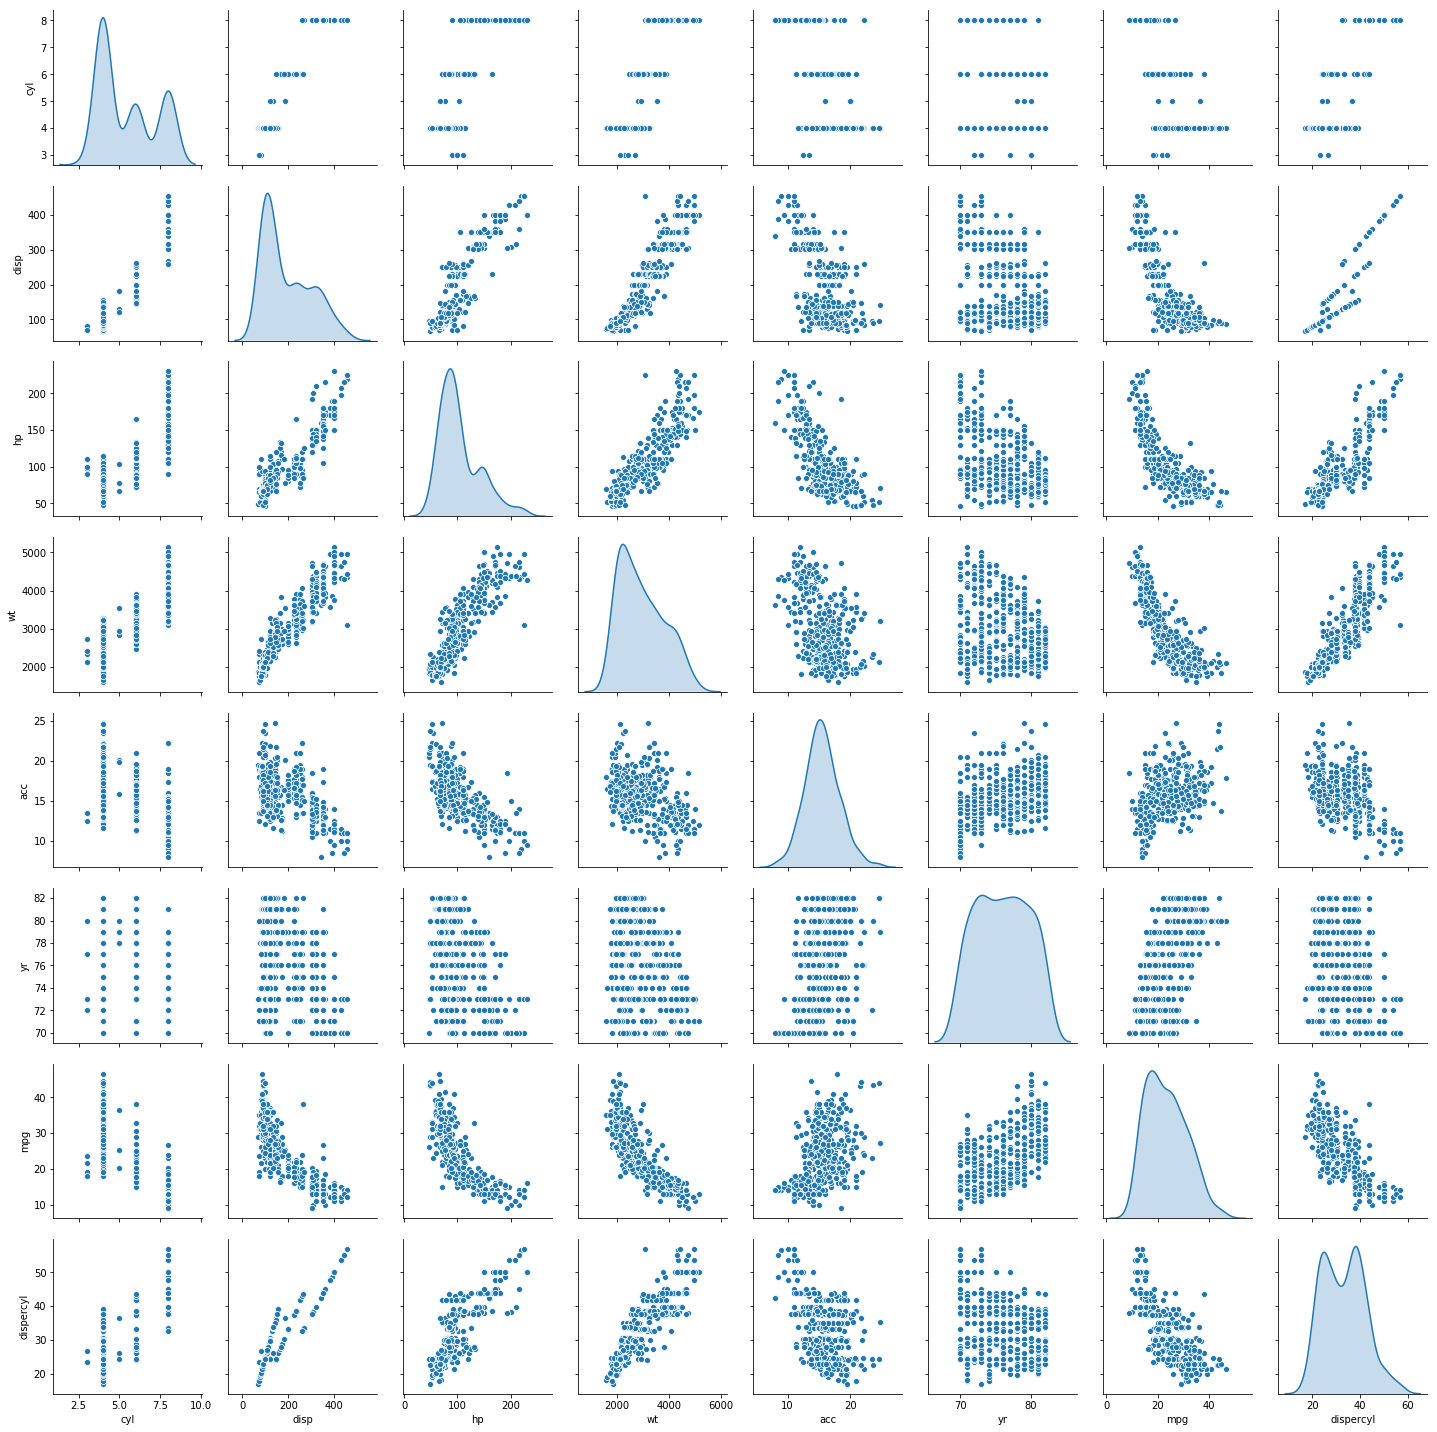

In [18]:
# This is done using scatter matrix function which creates a dashboard reflecting useful information about the dimensions
# The result can be stored as a .png file and opened in say, paint to get a larger view 

mpg_df_attr = mpg_df.iloc[:, 0:9]
mpg_df_attr['dispercyl'] = mpg_df_attr['disp'] / mpg_df_attr['cyl']
sns.pairplot(mpg_df_attr, diag_kind='kde')   # to plot density curve instead of histogram

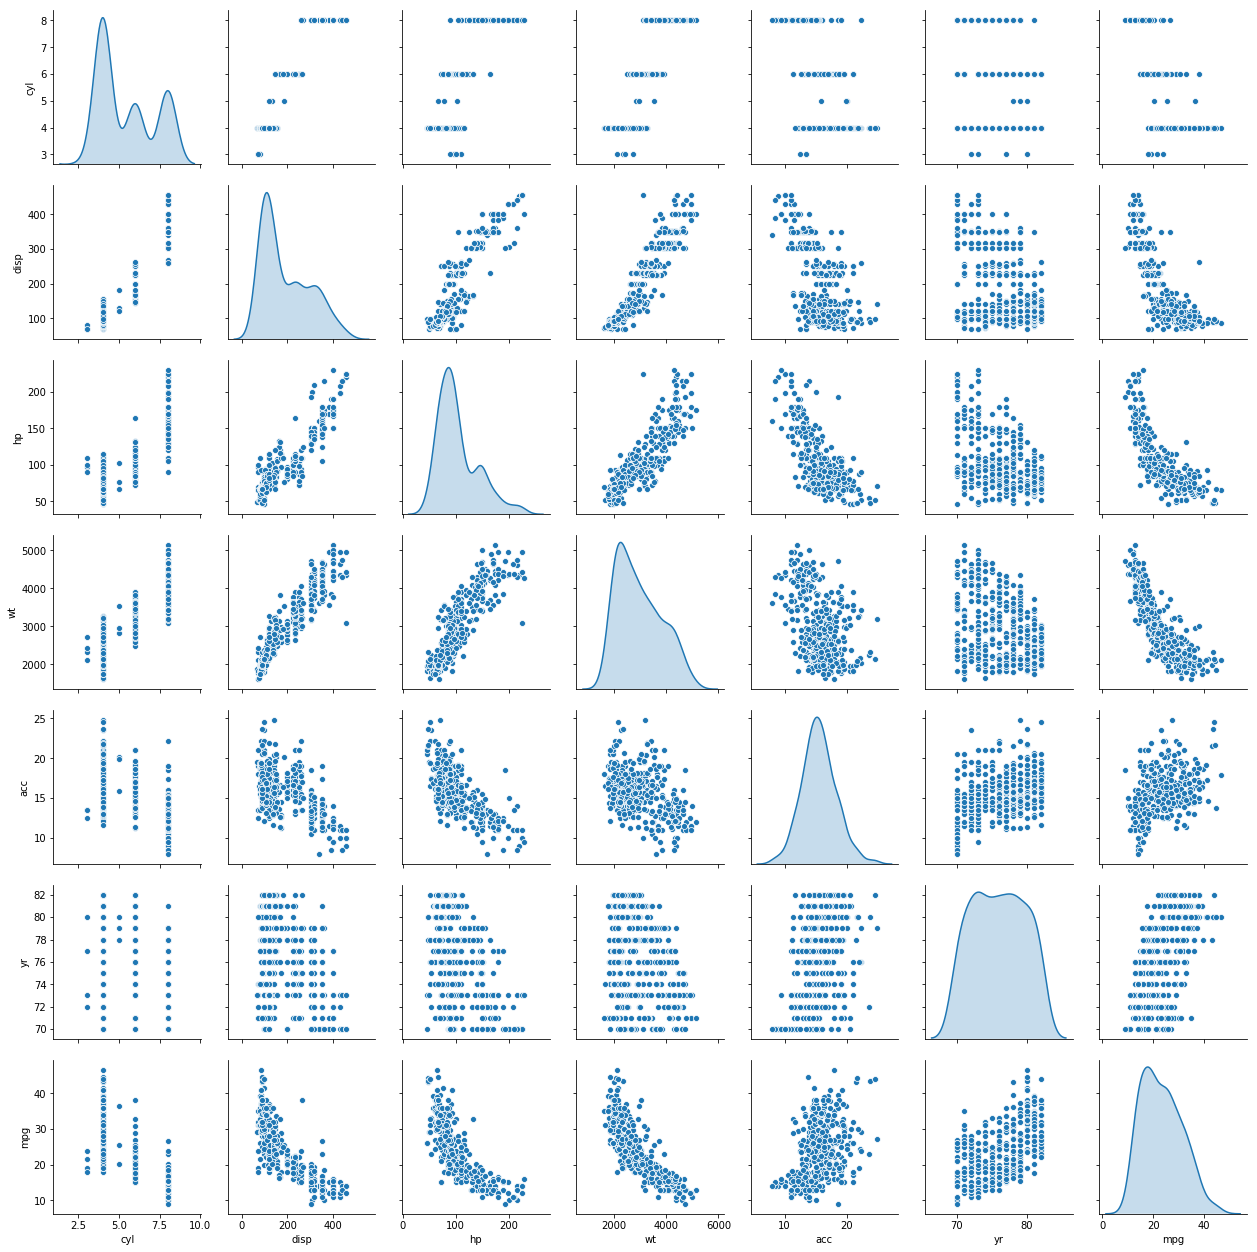

In [19]:
#Visually inspect the covariance between independent dimensions and between mpg and independent dimensions

sns.pairplot(mpg_df, diag_kind='kde') 

#Displacement is positively correlated to cylinders, horsepower and weight
#Horsepower is positively correlated to cylinders, displacement and weight
#Horspower is negatively correlated to acceleration
#Weight ~ mpg scatterplot indicates that the relationship may not be linear and the variable may require some transformation.

#There are 3 peaksin Cyl, disp and hp
 #With visual identification of the plots it is most likely to have 3 clusters in the data

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:2: FutureWarning: pandas.scatter_matrix is deprecated, use pandas.plotting.scatter_matrix instead
  


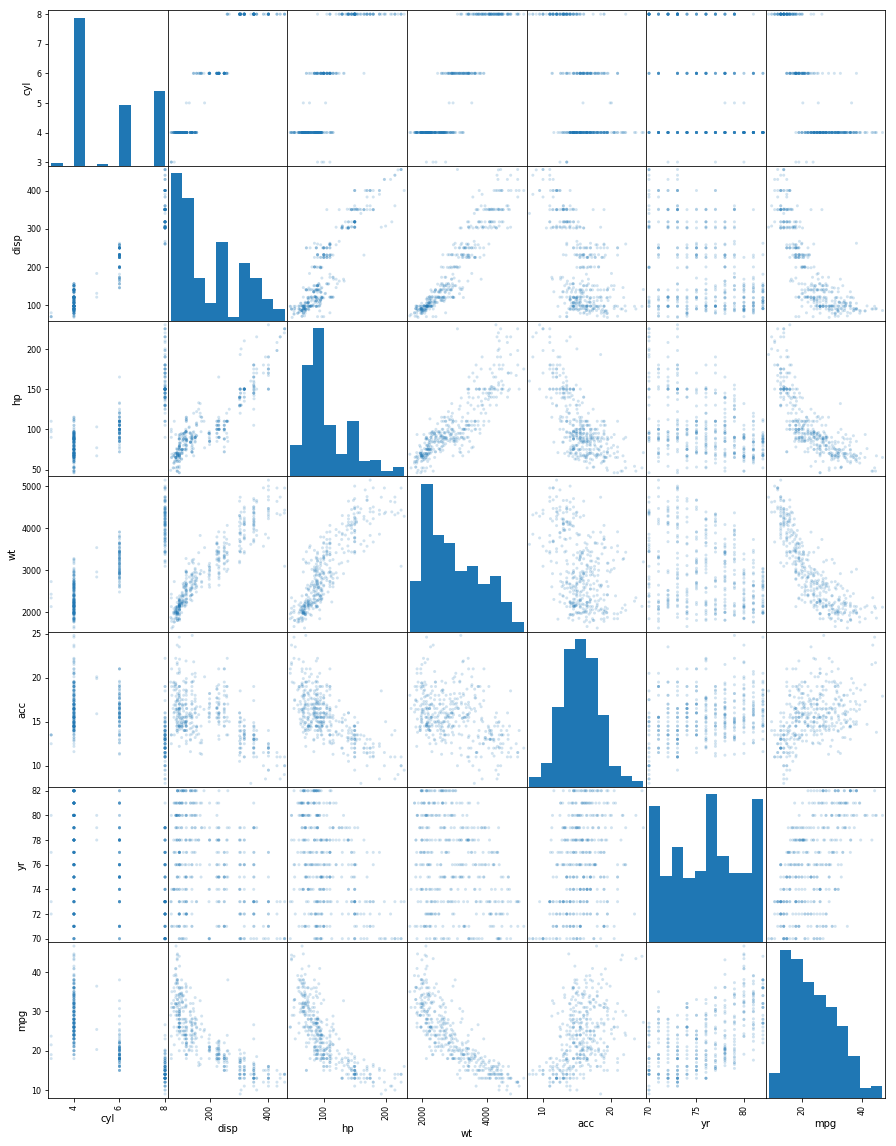

In [20]:
#Scatter matix
pd.scatter_matrix(mpg_df, alpha=0.2, figsize=(15, 20))
plt.show()

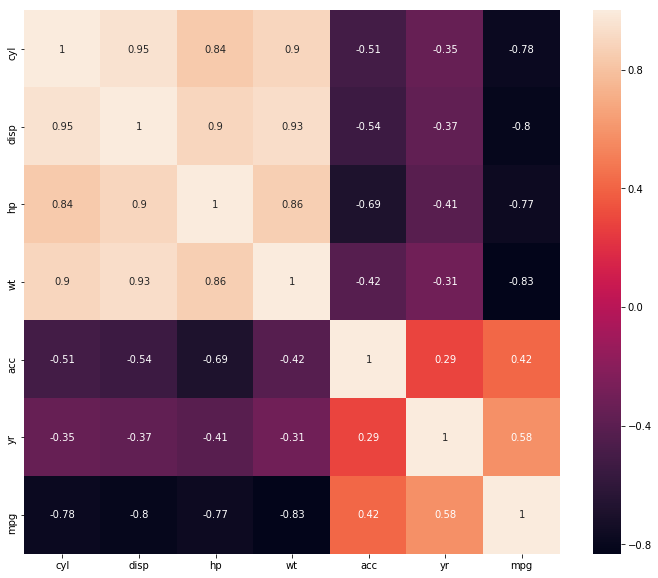

In [21]:
plt.figure(figsize=(12,10))
sns.heatmap(mpg_df.corr(),annot=True)

In [22]:
#Inter correlation between each variable is as given below.
mpg_df.corr().abs().unstack().sort_values(ascending=False).drop_duplicates()
#The top items in the below list are highly correlated

mpg   mpg     1.000000
cyl   disp    0.950721
wt    disp    0.932824
cyl   wt      0.896017
disp  hp      0.895778
hp    wt      0.862442
cyl   hp      0.841284
wt    mpg     0.831741
mpg   disp    0.804203
cyl   mpg     0.775396
hp    mpg     0.773453
      acc     0.686590
mpg   yr      0.579267
acc   disp    0.543684
      cyl     0.505419
      mpg     0.420289
wt    acc     0.417457
yr    hp      0.413733
disp  yr      0.370164
cyl   yr      0.348746
wt    yr      0.306564
yr    acc     0.288137
dtype: float64

In [23]:
#Displacement is highly correlated with cylinders, horsepower and weight are highly correlated.
#Weight is highly positively correlated with cylinders, displacement and horsepower

In [24]:
mpg_df.dtypes

cyl       int64
disp    float64
hp      float64
wt        int64
acc     float64
yr        int64
mpg     float64
dtype: object

In [25]:
from scipy.stats import zscore
X = mpg_df[mpg_df.columns[1:-1]]
y = mpg_df["mpg"]

#mpg_df_attr = mpg_df.loc[:, 'mpg']
mpg_df_attr_z = mpg_df.apply(zscore)

#Remove "yr" columns
mpg_df_attr_z.pop('yr')

array = mpg_df_attr_z.values

In [26]:
mpg_df_attr_z.head()

,cyl,disp,hp,wt,acc,mpg
0,1.498191,1.090604,0.673118,0.630870,-1.295498,-0.706439
1,1.498191,1.503514,1.589958,0.854333,-1.477038,-1.090751
2,1.498191,1.196232,1.197027,0.550470,-1.658577,-0.706439
3,1.498191,1.061796,1.197027,0.546923,-1.295498,-0.962647
4,1.498191,1.042591,0.935072,0.565841,-1.840117,-0.834543


In [27]:
X_train, X_test, y_train, y_test = train_test_split(mpg_df_attr_z, y, test_size=0.30, random_state=1)

In [28]:
# We transform (centralize) the entire X (independent variable data) to zscores through transformation. We will create the PCA dimensions
# on this distribution. 
sc = StandardScaler()
X_std =  sc.fit_transform(X)          
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[ 1.00251889  0.89803457  0.93517383 -0.54505356 -0.37109656]
 [ 0.89803457  1.00251889  0.86461476 -0.68831918 -0.41477495]
 [ 0.93517383  0.86461476  1.00251889 -0.41850885 -0.30733654]
 [-0.54505356 -0.68831918 -0.41850885  1.00251889  0.28886274]
 [-0.37109656 -0.41477495 -0.30733654  0.28886274  1.00251889]]


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:625: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\ProgramData\Anaconda3\lib\site-packages\sklearn\base.py:462: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


In [29]:
#X_std=StandardScaler().fit_transform(X)
#Dimentioanlity Reduction by PCA
#from sklearn.decomposition import PCA
# Perform PCA
#pca_auto= PCA()
#pca_auto.fit(X_std)
#pca_auto.explained_variance_ratio_.sum()

In [30]:
cluster_range = range( 2, 8)   # expect 3 to four clusters from the pair panel visual inspection hence restricting from 2 to 8
cluster_errors = []
for num_clusters in cluster_range:
  clusters = KMeans(  n_clusters = num_clusters, random_state = 2354)
  clusters.fit(X)
  labels = clusters.labels_
  centroids = clusters.cluster_centers_
  cluster_errors.append( clusters.inertia_ )
clusters_df = pd.DataFrame( { "num_clusters":cluster_range, "cluster_errors": cluster_errors } )
clusters_df

,num_clusters,cluster_errors
0,2,7.427761e+07
1,3,3.419856e+07
2,4,1.904318e+07
3,5,1.376146e+07
4,6,1.031184e+07
5,7,7.655135e+06


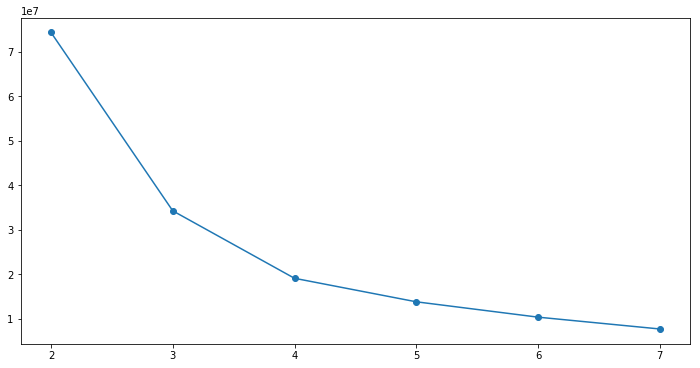

In [31]:
plt.figure(figsize=(12,6))
plt.plot( clusters_df.num_clusters, clusters_df.cluster_errors, marker = "o" )

The elbow plot confirms our visual analysis that there are likely 3 or 4 good clusters

In [82]:
#Let us try with k=4 first and then try k=3

In [32]:
cluster = KMeans( n_clusters = 4, random_state = 2354 )
cluster.fit(mpg_df_attr_z)
prediction=cluster.predict(mpg_df_attr_z)
# prediction
mpg_df_attr_z["GROUP"] = prediction
# df_filtered_z

In [33]:
# Find the centroids
centroids = cluster.cluster_centers_
centroids

array([[-0.84746902, -0.75211548, -0.48243632, -0.70707286, -0.19616096,
         0.56930351],
       [ 0.40212541,  0.29436282, -0.08700192,  0.32691222,  0.34920732,
        -0.51001261],
       [ 1.4860546 ,  1.48450715,  1.50624078,  1.38753374, -1.06267868,
        -1.15110476],
       [-0.81998551, -0.85895557, -0.91817479, -0.85174625,  1.21960744,
         0.99149249]])

In [34]:
centroid_df = pd.DataFrame(centroids, columns =  mpg_df_attr_z.columns.drop("GROUP"))
centroid_df

,cyl,disp,hp,wt,acc,mpg
0,-0.847469,-0.752115,-0.482436,-0.707073,-0.196161,0.569304
1,0.402125,0.294363,-0.087002,0.326912,0.349207,-0.510013
2,1.486055,1.484507,1.506241,1.387534,-1.062679,-1.151105
3,-0.819986,-0.858956,-0.918175,-0.851746,1.219607,0.991492


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000001E2E45F96A0>,
      dtype=object)

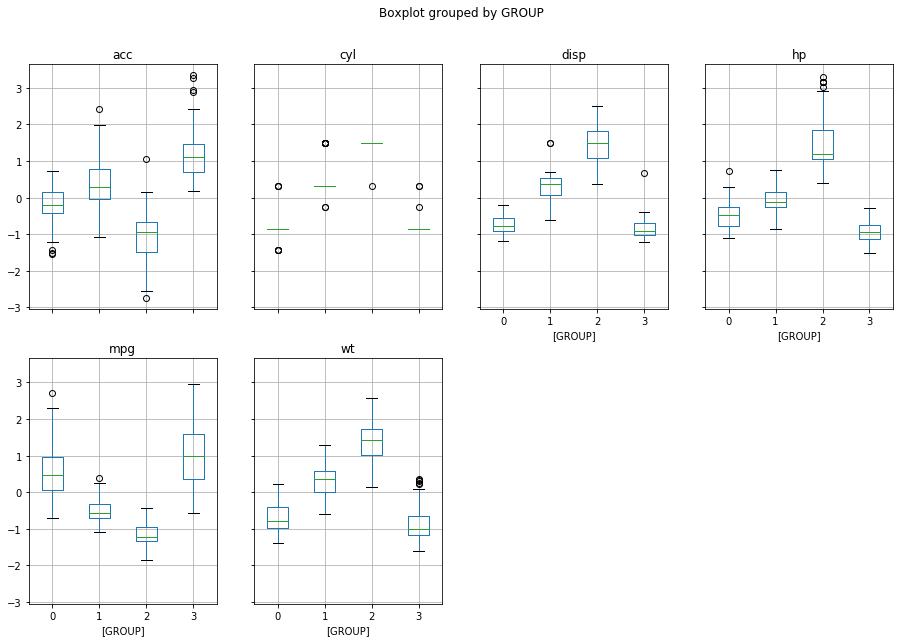

In [35]:
mpg_df_attr_z.boxplot(by = 'GROUP',  layout=(2,4), figsize=(15, 10))

In [36]:
# There are many outliers on each dimension  (indicated by the black circles)
# Spread of data on each dimension (indivated by the whiskers is long ... due to the outliers)
# If the outliers are addressed, the clusters will overlap much less than right now (except in year dimension which has no outlier)

In [37]:
# Addressing outliers at group level

data = mpg_df_attr_z   
       
def replace(group):
    median, std = group.median(), group.std()  #Get the median and the standard deviation of every group 
    outliers = (group - median).abs() > 2*std # Subtract median from every member of each group. Take absolute values > 2std
    group[outliers] = group.median()       
    return group

data_corrected = (data.groupby('GROUP').transform(replace)) 
concat_data = data_corrected.join(pd.DataFrame(mpg_df_attr_z['GROUP']))


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000001E2E4389BA8>,
      dtype=object)

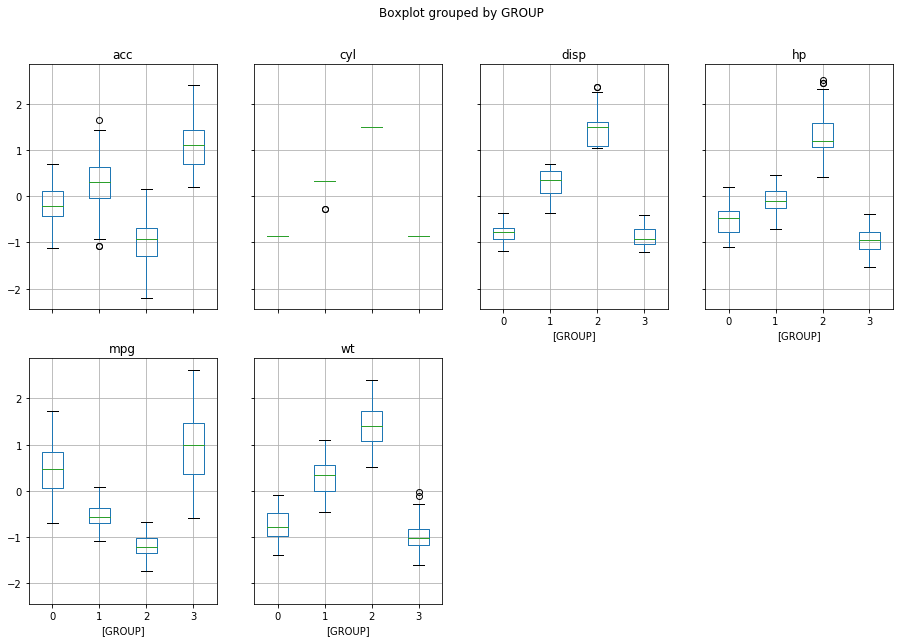

In [38]:
concat_data.boxplot(by = 'GROUP', layout=(2,4), figsize=(15, 10))

When we remove outliers and replace with median or mean, the distribution shape changes, the standard deviation becomes tighter creating new outliers. The new outliers would be much closer to the centre than original outliers so we accept them without modifying them

C:\ProgramData\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


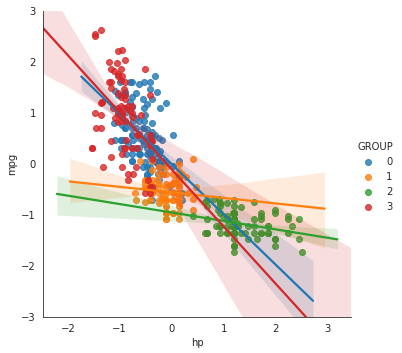

In [39]:
# mpg Vs hp

var = 'hp'

with sns.axes_style("white"):
    plot = sns.lmplot(var,'mpg',data=concat_data,hue='GROUP')
plot.set(ylim = (-3,3))

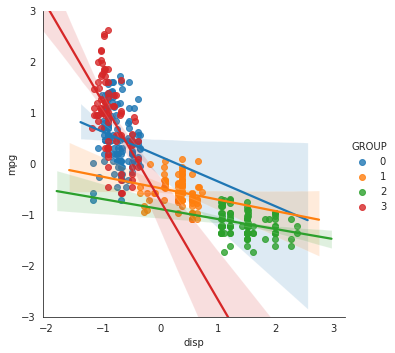

In [40]:
var = 'disp'
with sns.axes_style("white"):
    plot = sns.lmplot(var,'mpg',data=concat_data,hue='GROUP')
plot.set(ylim = (-3,3))

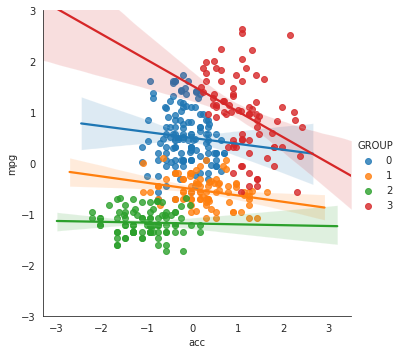

In [41]:
var = 'acc'
with sns.axes_style("white"):
    plot = sns.lmplot(var,'mpg',data=concat_data,hue='GROUP')
plot.set(ylim = (-3,3))

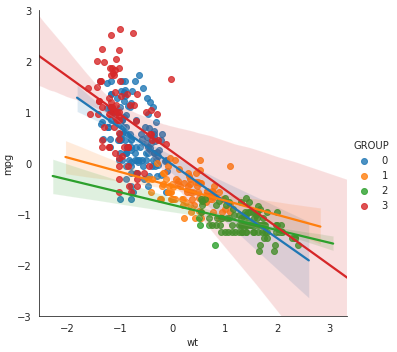

In [42]:
var = 'wt'
with sns.axes_style("white"):
    plot = sns.lmplot(var,'mpg',data=concat_data,hue='GROUP')
plot.set(ylim = (-3,3))

In [43]:
# Let us break the data into largecar and smallcar segments

largecar = concat_data[concat_data['GROUP']==1]
smallcar = concat_data[concat_data['GROUP']==0]
sedancar = concat_data[concat_data['GROUP']==2]
minicar  = concat_data[concat_data['GROUP']==3]

C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2
C:\ProgramData\Anaconda3\lib\site-packages\numpy\core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


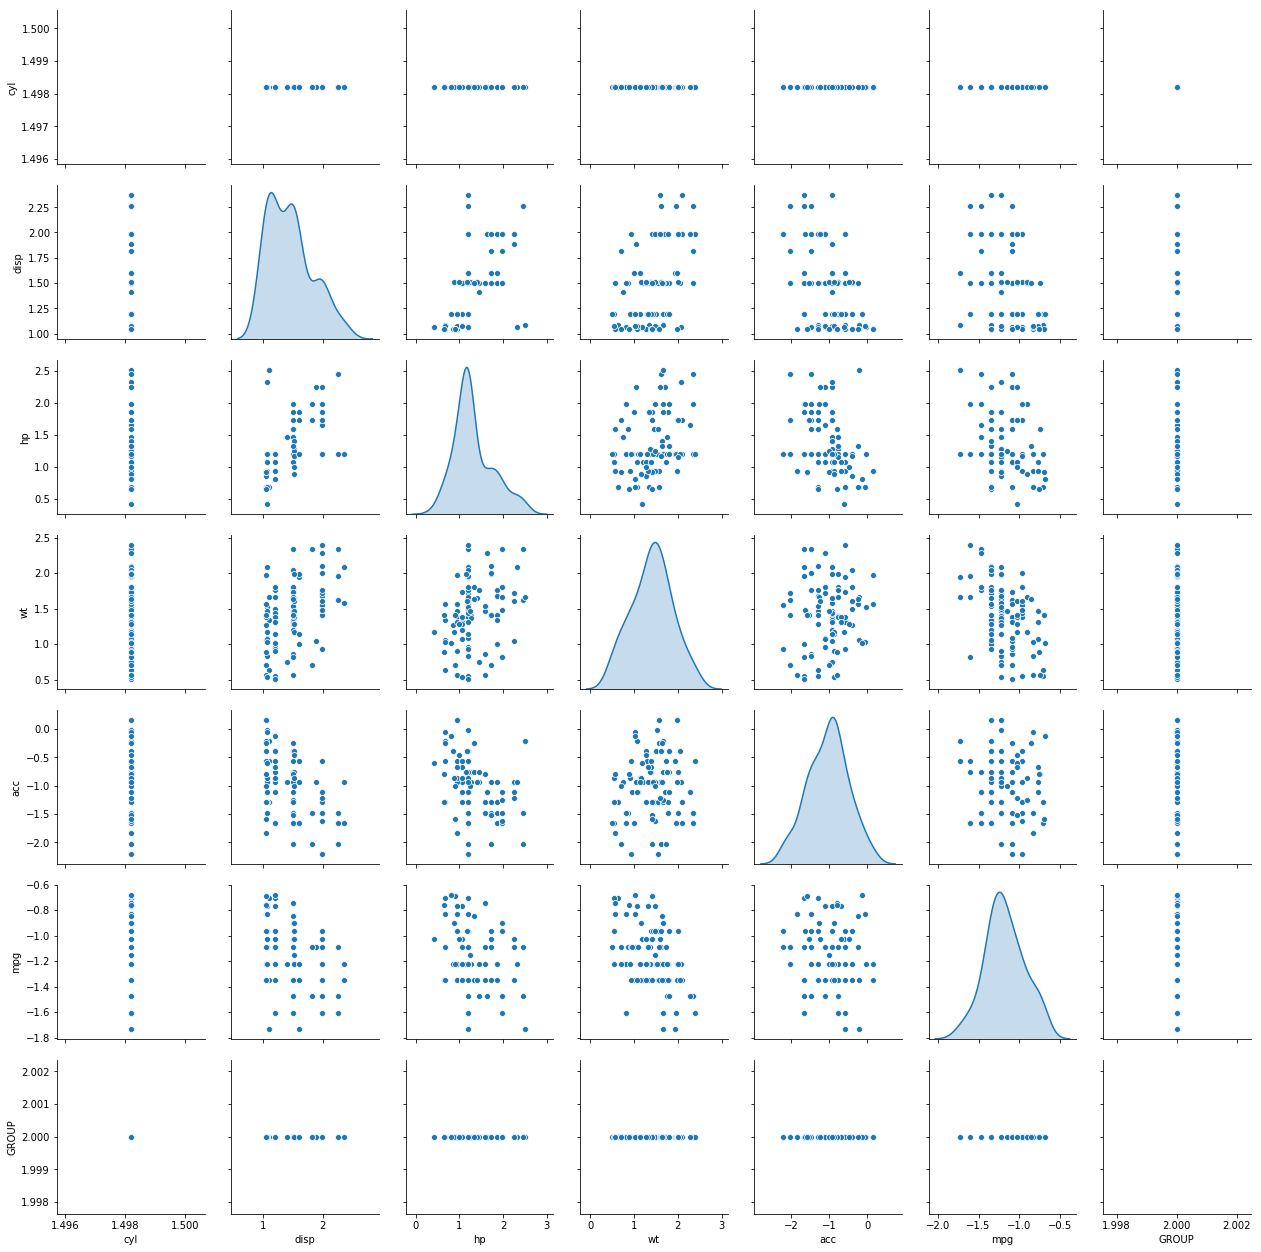

In [44]:
# Let us look at largecar pair panel

mpg_df_attr = sedancar.iloc[:, 0:8]   # CHANGE THE CARTYPE AT THIS POINT TO CHECK HOW THE MODEL PERFORMS FOR EACH GROUP

sns.pairplot(mpg_df_attr, diag_kind='kde')   # to plot density curve instead of histogram

#sns.pairplot(mpg_df_attr)  # to plot histogram, the default

In [45]:
mpg_df_attr.shape

(97, 7)

In [46]:
#On full data set
X = mpg_df_attr_z.drop("mpg", axis=1)
y = mpg_df_attr_z["mpg"]
test_size = 0.3 # taking 70:30 training and test set
seed = 7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

print("Train Count:", X_train.shape)
print("Test Count:", X_test.shape)

Train Count: (278, 6)
Test Count: (120, 6)


#linear regression on complete data

In [47]:
#linear regression on complete data
model=LinearRegression()
  
model.fit(X_train, y_train)
print("linear model coeffs", model.coef_)
print("linear model intercept", model.intercept_)
print("linear model score", model.score(X_test, y_test))

linear model coeffs [-0.30094257 -0.04161456 -0.27107893 -0.40482117 -0.17245509  0.14108478]
linear model intercept -0.17806022166577515
linear model score 0.6728939572491557


linear regression on each group with all independent variables

In [48]:
X = largecar.drop("mpg", axis=1)
y = largecar["mpg"]
test_size = 0.3 # taking 70:30 training and test set
seed = 7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

print("Train Count:", X_train.shape)
print("Test Count:", X_test.shape)

model=LinearRegression()
  
model.fit(X_train, y_train)
print("linear model coeffs", model.coef_)
print("linear model intercept", model.intercept_)
print("linear model score", model.score(X_test, y_test))

Train Count: (60, 6)
Test Count: (27, 6)
linear model coeffs [ 0.10381013  0.04849941 -0.0264072  -0.34836639  0.06797947  0.        ]
linear model intercept -0.468442923113885
linear model score -0.30187543020459695


In [49]:
X = smallcar.drop("mpg", axis=1)
y = smallcar["mpg"]
test_size = 0.3 # taking 70:30 training and test set
seed = 7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

print("Train Count:", X_train.shape)
print("Test Count:", X_test.shape)

model=LinearRegression()
  
model.fit(X_train, y_train)
print("linear model coeffs", model.coef_)
print("linear model intercept", model.intercept_)
print("linear model score", model.score(X_test, y_test))

Train Count: (93, 6)
Test Count: (40, 6)
linear model coeffs [-0.16228676  0.63992176 -1.02637015 -0.25230676 -0.22500685  0.        ]
linear model intercept 0.056734444374222204
linear model score 0.1527086431365431


In [50]:
X = sedancar.drop("mpg", axis=1)
y = sedancar["mpg"]
test_size = 0.3 # taking 70:30 training and test set
seed = 7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

print("Train Count:", X_train.shape)
print("Test Count:", X_test.shape)

model=LinearRegression()
  
model.fit(X_train, y_train)
print("linear model coeffs", model.coef_)
print("linear model intercept", model.intercept_)
print("linear model score", model.score(X_test, y_test))

Train Count: (67, 6)
Test Count: (30, 6)
linear model coeffs [ 0.18799297  0.01055231 -0.12755696 -0.19133038 -0.05642352  0.        ]
linear model intercept -1.0818616462069475
linear model score 0.2775478533143919


In [51]:
X = minicar.drop("mpg", axis=1)
y = minicar["mpg"]
test_size = 0.3 # taking 70:30 training and test set
seed = 7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

print("Train Count:", X_train.shape)
print("Test Count:", X_test.shape)

model=LinearRegression()
  
model.fit(X_train, y_train)
print("linear model coeffs", model.coef_)
print("linear model intercept", model.intercept_)
print("linear model score", model.score(X_test, y_test))

Train Count: (56, 6)
Test Count: (25, 6)
linear model coeffs [ 0.         -0.99086275 -0.9640592   0.12403693 -0.49032     0.        ]
linear model intercept -0.170936999398403
linear model score 0.26973564257479676


Do VIF to drop the highly correlated variable

In [52]:
#Let's use VIF to drop highly correlated data
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = mpg_df_attr_z.drop("mpg", axis=1)

vif = pd.DataFrame()
vif["features"] = X.columns
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif.sort_values(by="VIF Factor",ascending=False)
#vif

,features,VIF Factor
1,disp,19.701282
0,cyl,10.771951
3,wt,10.603095
2,hp,8.766344
4,acc,2.898680
5,GROUP,1.196419


In [53]:
#Drop "disp" which has very high VIF factor
X = mpg_df_attr_z.drop(["disp","mpg"], axis=1)

vif = pd.DataFrame()
vif["features"] = X.columns
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif.sort_values(by="VIF Factor",ascending=False)
#vif

,features,VIF Factor
2,wt,8.468727
1,hp,8.216663
0,cyl,6.059760
3,acc,2.855399
4,GROUP,1.192502


In [54]:
#linear regression on complete data
#On full data set with disp variable dropped
X = mpg_df_attr_z.drop(["disp","mpg"], axis=1)
y = mpg_df_attr_z["mpg"]
test_size = 0.3 # taking 70:30 training and test set
seed = 7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

print("Train Count:", X_train.shape)
print("Test Count:", X_test.shape)
model=LinearRegression()
  
model.fit(X_train, y_train)
print("linear model coeffs", model.coef_)
print("linear model intercept", model.intercept_)
print("linear model score", model.score(X_test, y_test))

Train Count: (278, 5)
Test Count: (120, 5)
linear model coeffs [-0.32117888 -0.28039282 -0.41717109 -0.17064022  0.14036025]
linear model intercept -0.17750493152887498
linear model score 0.6723521470420666


In [55]:
#Drop disp" which has very high VIF factor
X = largecar.drop(["mpg" ,"disp"], axis=1)
y = largecar["mpg"]
test_size = 0.3 # taking 70:30 training and test set
seed = 7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

print("Train Count:", X_train.shape)
print("Test Count:", X_test.shape)

model=LinearRegression()
  
model.fit(X_train, y_train)
print("linear model coeffs", model.coef_)
print("linear model intercept", model.intercept_)
print("linear model score", model.score(X_test, y_test))

Train Count: (60, 5)
Test Count: (27, 5)
linear model coeffs [ 0.07963167 -0.03731792 -0.32996339  0.06559506  0.        ]
linear model intercept -0.45444623565585396
linear model score -0.24766969205372222


In [56]:
#Drop disp" which has very high VIF factor
X = smallcar.drop(["mpg" ,"disp"], axis=1)
y = smallcar["mpg"]
test_size = 0.3 # taking 70:30 training and test set
seed = 7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

print("Train Count:", X_train.shape)
print("Test Count:", X_test.shape)

model=LinearRegression()
  
model.fit(X_train, y_train)
print("linear model coeffs", model.coef_)
print("linear model intercept", model.intercept_)
print("linear model score", model.score(X_test, y_test))

Train Count: (93, 5)
Test Count: (40, 5)
linear model coeffs [-0.16228676 -1.03591514  0.02907338 -0.23465993  0.        ]
linear model intercept -0.23230441449700995
linear model score 0.11686875645716122


In [57]:
#Drop disp" which has very high VIF factor
X = sedancar.drop(["mpg" ,"disp"], axis=1)
y = sedancar["mpg"]
test_size = 0.3 # taking 70:30 training and test set
seed = 7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

print("Train Count:", X_train.shape)
print("Test Count:", X_test.shape)

model=LinearRegression()
  
model.fit(X_train, y_train)
print("linear model coeffs", model.coef_)
print("linear model intercept", model.intercept_)
print("linear model score", model.score(X_test, y_test))

Train Count: (67, 5)
Test Count: (30, 5)
linear model coeffs [ 0.18799297 -0.12340663 -0.1878603  -0.05844344  0.        ]
linear model intercept -1.0789471690611052
linear model score 0.2810255416859466


In [58]:
#Drop disp" which has very high VIF factor
X = minicar.drop(["mpg" ,"disp"], axis=1)
y = minicar["mpg"]
test_size = 0.3 # taking 70:30 training and test set
seed = 7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

print("Train Count:", X_train.shape)
print("Test Count:", X_test.shape)

model=LinearRegression()
  
model.fit(X_train, y_train)
print("linear model coeffs", model.coef_)
print("linear model intercept", model.intercept_)
print("linear model score", model.score(X_test, y_test))

Train Count: (56, 5)
Test Count: (25, 5)
linear model coeffs [ 0.         -1.24184636 -0.10282044 -0.55987428  0.        ]
linear model intercept 0.29678537060447174
linear model score 0.1865877146988154


In [59]:
#As per the elbow curve the optimal no of clusters if 3
#Try with K=3

In [60]:
mpg_df_attr_z = mpg_df.apply(zscore)

#Remove "yr" columns
mpg_df_attr_z.pop('yr')

cluster = KMeans( n_clusters = 3,random_state = 2354 )
cluster.fit(mpg_df_attr_z)

prediction=cluster.predict(mpg_df_attr_z)
mpg_df_attr_z["GROUP"] = prediction

In [61]:
mpg_df_attr_z.columns

Index(['cyl', 'disp', 'hp', 'wt', 'acc', 'mpg', 'GROUP'], dtype='object')

In [62]:
centroids = cluster.cluster_centers_
centroids

array([[ 1.4860546 ,  1.48450715,  1.50624078,  1.38753374, -1.06267868,
        -1.15110476],
       [-0.85347696, -0.80321374, -0.67506194, -0.78549879,  0.36133415,
         0.75394661],
       [ 0.34598334,  0.23689416, -0.06773972,  0.29795187,  0.30089004,
        -0.47244453]])

In [63]:
centroid_df = pd.DataFrame(centroids, columns =  mpg_df_attr_z.columns.drop("GROUP"))
centroid_df

,cyl,disp,hp,wt,acc,mpg
0,1.486055,1.484507,1.506241,1.387534,-1.062679,-1.151105
1,-0.853477,-0.803214,-0.675062,-0.785499,0.361334,0.753947
2,0.345983,0.236894,-0.067740,0.297952,0.300890,-0.472445


In [64]:
# Addressing outliers at group level

data = mpg_df_attr_z   # lazy to type long names. Renaming it to data. Remember data is not a copy of the dataframe
       
def replace(group):
    median, std = group.median(), group.std()  #Get the median and the standard deviation of every group 
    outliers = (group - median).abs() > 2*std # Subtract median from every member of each group. Take absolute values > 2std
    group[outliers] = group.median()       
    return group

data_corrected = (data.groupby('GROUP').transform(replace)) 
concat_data = data_corrected.join(pd.DataFrame(mpg_df_attr_z['GROUP']))


C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000001E2E4422860>,
      dtype=object)

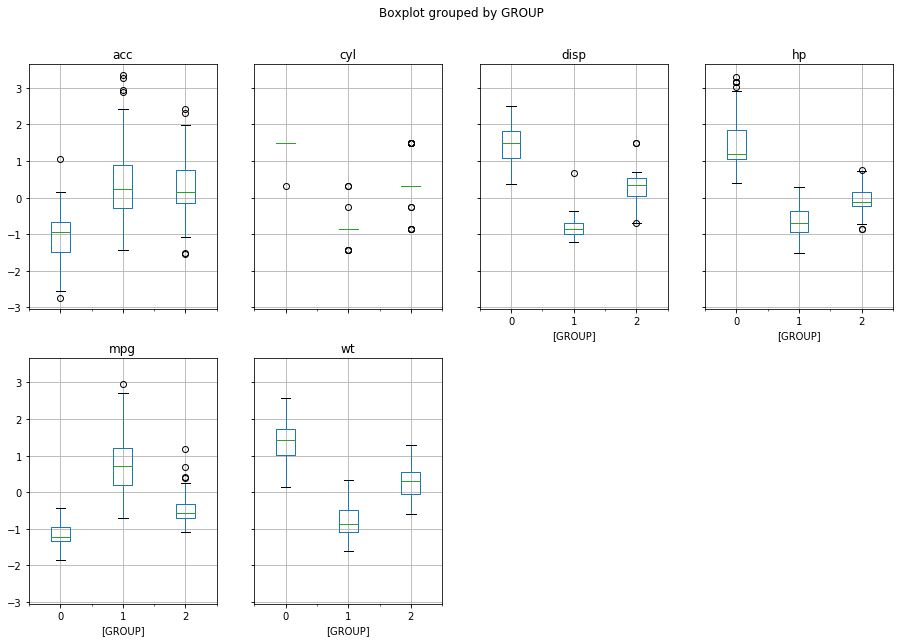

In [65]:
mpg_df_attr_z.boxplot(by = 'GROUP',  layout=(2,4), figsize=(15, 10))

C:\ProgramData\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


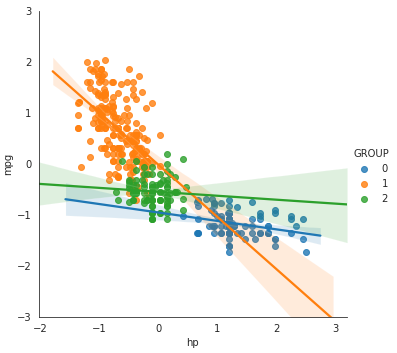

In [66]:
# mpg Vs hp

var = 'hp'

with sns.axes_style("white"):
    plot = sns.lmplot(var,'mpg',data=concat_data,hue='GROUP')
plot.set(ylim = (-3,3))

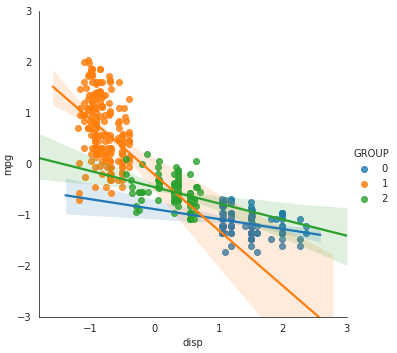

In [67]:
var = 'disp'
with sns.axes_style("white"):
    plot = sns.lmplot(var,'mpg',data=concat_data,hue='GROUP')
plot.set(ylim = (-3,3))

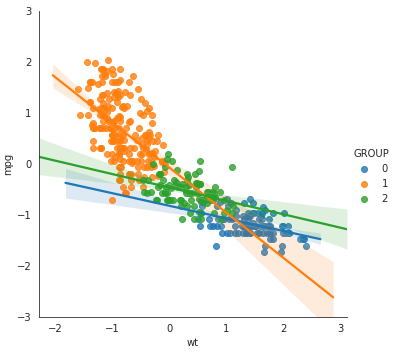

In [68]:
var = 'wt'
with sns.axes_style("white"):
    plot = sns.lmplot(var,'mpg',data=concat_data,hue='GROUP')
plot.set(ylim = (-3,3))

In [69]:
# Let us break the data into largecar and smallcar segments

largecar = concat_data[concat_data['GROUP']==0]
smallcar = concat_data[concat_data['GROUP']==1]
sedancar = concat_data[concat_data['GROUP']==2]

C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2
C:\ProgramData\Anaconda3\lib\site-packages\numpy\core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


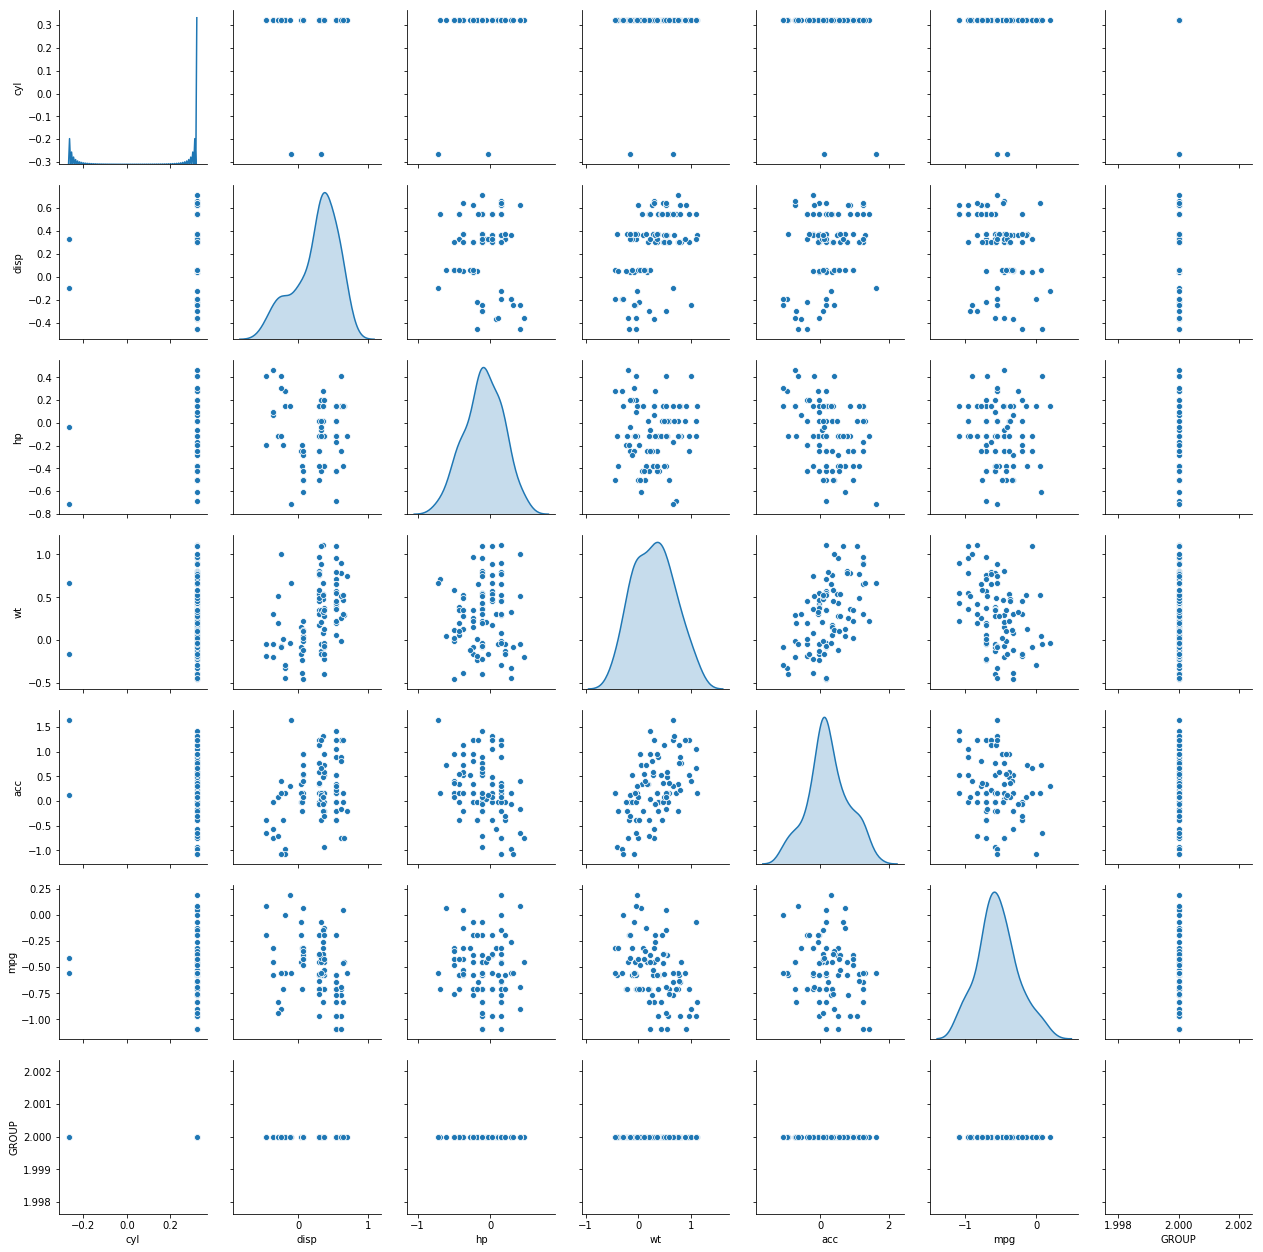

In [70]:
# Let us look at car pair panel

mpg_df_attr = sedancar.iloc[:, 0:8]

sns.pairplot(mpg_df_attr, diag_kind='kde')   # to plot density curve instead of histogram

#sns.pairplot(mpg_df_attr)  # to plot histogram, the default

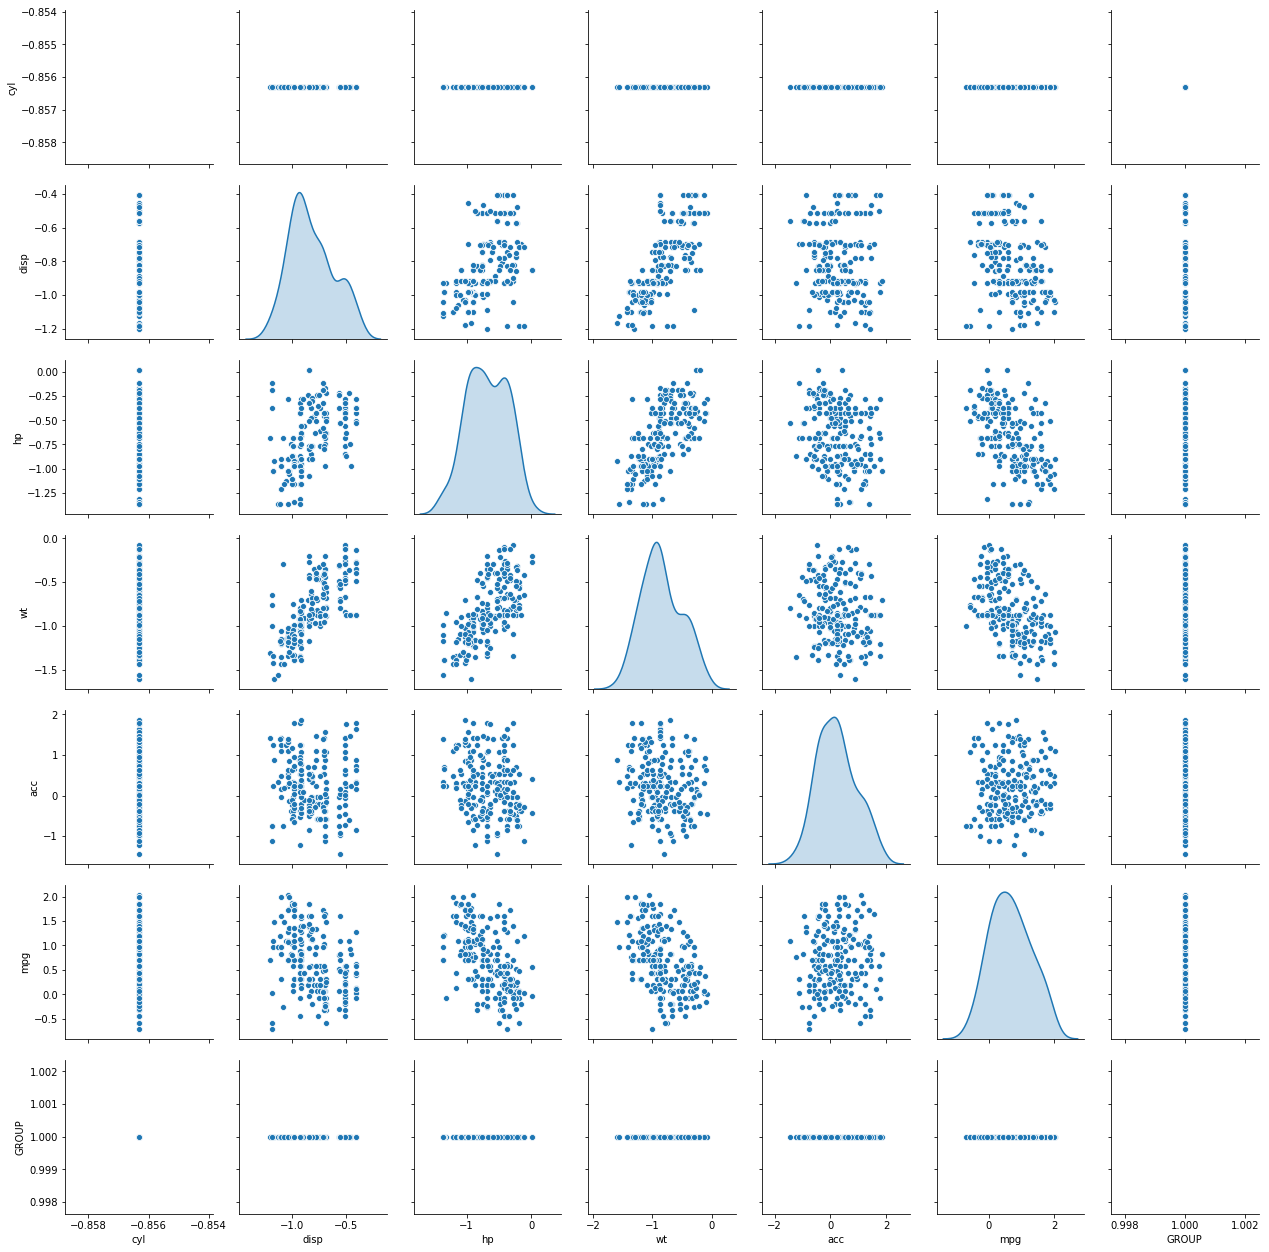

In [71]:
# Let us look at car pair panel

mpg_df_attr = smallcar.iloc[:, 0:8]

sns.pairplot(mpg_df_attr, diag_kind='kde')   # to plot density curve instead of histogram

#sns.pairplot(mpg_df_attr)  # to plot histogram, the default

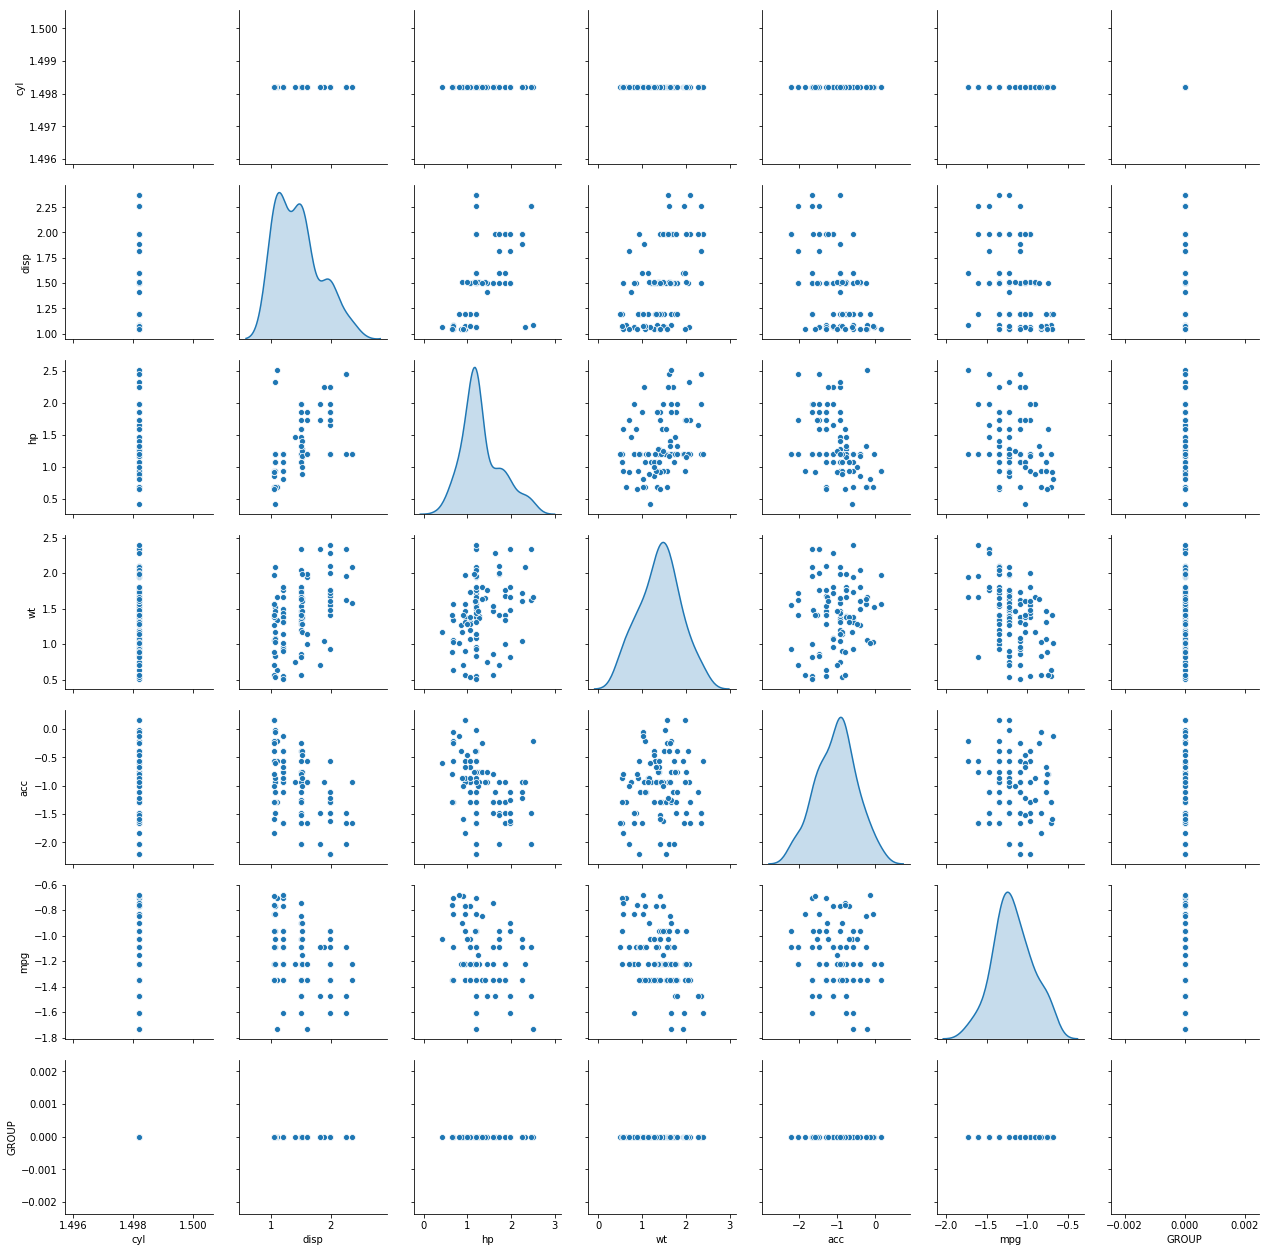

In [72]:
# Let us look at car pair panel

mpg_df_attr =largecar.iloc[:, 0:8]

sns.pairplot(mpg_df_attr, diag_kind='kde')   # to plot density curve instead of histogram

#sns.pairplot(mpg_df_attr)  # to plot histogram, the default

In [73]:
# Most of the attributes are now showing almost gaussian distribution 
# The interaction between dimensions too is relatively more linear
# But there is a lot of spread.

In [74]:
X = largecar.drop("mpg", axis=1)
y = largecar["mpg"]
test_size = 0.3 # taking 70:30 training and test set
seed = 7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

print("Train Count:", X_train.shape)
print("Test Count:", X_test.shape)

model=LinearRegression()
  
model.fit(X_train, y_train)
print("linear model coeffs", model.coef_)
print("linear model intercept", model.intercept_)
print("linear model score", model.score(X_test, y_test))

Train Count: (67, 6)
Test Count: (30, 6)
linear model coeffs [ 0.18799297  0.01055231 -0.12755696 -0.19133038 -0.05642352  0.        ]
linear model intercept -1.0818616462069475
linear model score 0.2775478533143919


In [75]:
X = smallcar.drop("mpg", axis=1)
y = smallcar["mpg"]
test_size = 0.3 # taking 70:30 training and test set
seed = 7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

print("Train Count:", X_train.shape)
print("Test Count:", X_test.shape)

model=LinearRegression()
  
model.fit(X_train, y_train)
print("linear model coeffs", model.coef_)
print("linear model intercept", model.intercept_)
print("linear model score", model.score(X_test, y_test))

Train Count: (144, 6)
Test Count: (63, 6)
linear model coeffs [ 0.          0.11129481 -0.81351588 -0.35012192 -0.0720853   0.        ]
linear model intercept -0.0649076206767154
linear model score 0.3877046974702861


In [76]:
X = sedancar.drop("mpg", axis=1)
y = sedancar["mpg"]
test_size = 0.3 # taking 70:30 training and test set
seed = 7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

print("Train Count:", X_train.shape)
print("Test Count:", X_test.shape)

model=LinearRegression()
  
model.fit(X_train, y_train)
print("linear model coeffs", model.coef_)
print("linear model intercept", model.intercept_)
print("linear model score", model.score(X_test, y_test))

Train Count: (65, 6)
Test Count: (29, 6)
linear model coeffs [ 0.12807522 -0.16354623 -0.23185603 -0.0993425  -0.08243181  0.        ]
linear model intercept -0.505678008603234
linear model score 0.18466341718222912


In [77]:
#Drop "disp" which has very high VIF factor
X = largecar.drop(["mpg" ,"disp"], axis=1)
y = largecar["mpg"]
test_size = 0.3 # taking 70:30 training and test set
seed = 7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

print("Train Count:", X_train.shape)
print("Test Count:", X_test.shape)

model=LinearRegression()
  
model.fit(X_train, y_train)
print("linear model coeffs", model.coef_)
print("linear model intercept", model.intercept_)
print("linear model score", model.score(X_test, y_test))

Train Count: (67, 5)
Test Count: (30, 5)
linear model coeffs [ 0.18799297 -0.12340663 -0.1878603  -0.05844344  0.        ]
linear model intercept -1.0789471690611052
linear model score 0.2810255416859466


In [78]:
#Drop "disp" which has very high VIF factor
X = smallcar.drop(["mpg" ,"disp"], axis=1)
y = smallcar["mpg"]
test_size = 0.3 # taking 70:30 training and test set
seed = 7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

print("Train Count:", X_train.shape)
print("Test Count:", X_test.shape)

model=LinearRegression()
  
model.fit(X_train, y_train)
print("linear model coeffs", model.coef_)
print("linear model intercept", model.intercept_)
print("linear model score", model.score(X_test, y_test))

Train Count: (144, 5)
Test Count: (63, 5)
linear model coeffs [ 0.         -0.80686395 -0.30696167 -0.06938091  0.        ]
linear model intercept -0.11781116229901545
linear model score 0.3876177664782646


In [79]:
#Drop "disp" which has very high VIF factor
X = sedancar.drop(["mpg" ,"disp"], axis=1)
y = sedancar["mpg"]
test_size = 0.3 # taking 70:30 training and test set
seed = 7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

print("Train Count:", X_train.shape)
print("Test Count:", X_test.shape)

model=LinearRegression()
  
model.fit(X_train, y_train)
print("linear model coeffs", model.coef_)
print("linear model intercept", model.intercept_)
print("linear model score", model.score(X_test, y_test))

Train Count: (65, 5)
Test Count: (29, 5)
linear model coeffs [-0.05956647 -0.20272126 -0.15494383 -0.08926071  0.        ]
linear model intercept -0.470673467258261
linear model score 0.12169543320413057


Summary

In [83]:
#Here is the sumamry of scores:
#All cars groups in one dataset with all variables even if they are highly correlated:
    #Model Score:   0.6728939572491557
#All cars groups in one dataset with highly correlated variable "displacement" dropped
    #Model Score:   0.6596299563820268
    
#With K=4
#large car: linear model score -0.30187543020459695
#small car: linear model score 0.1527086431365431
#sedan car: linear model score 0.2775478533143919
#mini car: linear model score 0.26973564257479676
#drop displacement variable: large car: linear model score -0.24766969205372222
#drop displacement variable: small car: linear model score 0.11686875645716122
#drop displacement variable: sedan car: linear model score 0.2810255416859466
#drop displacement variable: mini car: linear model score 0.1865877146988154


#With K=3
#large car: linear model score 0.2775478533143919
#small car: linear model score 0.3877046974702861
#sedan car: linear model score 0.18466341718222912
#drop displacement variable: large car: linear model score 0.2810255416859466
#drop displacement variable: small car: linear model score 0.3876177664782646
#drop displacement variable: sedan car: linear model score 0.12169543320413057

In [81]:
#Optimal number of clusters = 3 and the scores are better with k=3